# EmporiUm Sales Territory Analysis
### Capstone 2: Business Analysis with Python — Samia

---

## Project Overview
EmporiUm is a growing student bookstore chain that sells books, tech gear, art supplies, and other
products both in-store and online. Sales are organized by region, with each region divided into
sales territories managed by a territory manager.

This notebook compares two assigned sales territories — **Massachusetts** and **New Jersey** —
both located in the **Northeast region**, as part of a core marketing analysis for the retail
marketing team.

## Assigned Sales Territories

| Detail | Territory 1 | Territory 2 |
|---|---|---|
| **State** | Massachusetts | New Jersey |
| **Territory Manager** | Bo Heap | Miami Vue |
| **Region** | Northeast | Northeast |
| **Number of Stores** | 18 | 16 |
| **Data Period** | January 2022 – September 2025 | January 2022 – September 2025 |

## Analysis Goals
- Identify territory managers and store details for each territory
- Calculate monthly total revenue for each territory over the full data period
- Rank store performance and identify top-performing locations
- Identify top customers using rewards ID data
- Analyze transactions and revenue by product category
- Provide marketing recommendations for the next quarter


## Step 1: Import Libraries

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


## Step 2: Load Data

### Customer List
This file contains EmporiUm rewards program members. It is pipe-delimited (`|`) rather than
comma-delimited, so we pass `sep='|'` to `read_csv()`. We also strip whitespace from column
names to avoid hidden spacing issues.


In [44]:
df_customers = pd.read_csv('customer_list.csv', sep='|')
df_customers.columns = df_customers.columns.str.strip()
df_customers.info()


<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cust_id      521 non-null    int64
 1   date         521 non-null    str  
 2   time         521 non-null    str  
 3   name         521 non-null    str  
 4   email        521 non-null    str  
 5   phone        520 non-null    str  
 6   sms-opt-out  520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [45]:
df_customers.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


### Product Categories
Maps `CategoryID` and `SubcategoryID` to human-readable category and subcategory names.
We will use this later to join against the Products and Sales data.


In [46]:
df_categories = pd.read_csv('ProductCategories.csv')
df_categories.info()


<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [47]:
df_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


### Products
Contains individual product records with their associated `CategoryID` and `SubcategoryID`.
This links the sales transaction data to product category information.


In [48]:
df_products = pd.read_csv('Products.csv')
df_products.info()


<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [49]:
df_products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


### Store Detail
Contains one row per store with its location, territory manager, region, and state.
We will use this to filter sales data down to our two assigned territories.


In [50]:
df_stores = pd.read_csv('StoreDetail.csv')
df_stores.info()


<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [51]:
df_stores.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


### Store Sales
The main transaction dataset. Each row is a single sale, including the store, date, product,
rewards member ID (if applicable), and sale amount. This is the core of our analysis.


In [52]:
df_sales = pd.read_csv('StoreSales.csv')
df_sales.info()


<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


In [53]:
df_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


---
## Step 5: Core Marketing Analysis

The following sections address each marketing question assigned for this capstone.
Each question is broken into smaller steps using a combination of markdown explanations
and code blocks, followed by a written finding summarizing the results.


---
## Section 6: Marketing Manager Analysis Questions


### 6.1 — Territory Managers and Store Information

**Question:** Who are the territory managers for the assigned sales territories?
What are the store IDs and cities for the stores in each territory?

**Approach:**
- Filter the `StoreDetail` DataFrame by state to isolate each territory
- Display the territory manager name, region, and full list of store IDs with city names


In [12]:
# Filter StoreDetail to each assigned territory by state
ma_stores = df_stores[df_stores['State'] == 'Massachusetts'].copy()
nj_stores = df_stores[df_stores['State'] == 'New Jersey'].copy()


In [54]:
# Print territory summary and store list for each territory
for label, stores in [('Massachusetts', ma_stores), ('New Jersey', nj_stores)]:
    print(f"Territory : {label}")
    print(f"Manager   : {stores['Territory Manager'].iloc[0]}")
    print(f"Region    : {stores['Region'].iloc[0]}")
    print(f"# Stores  : {len(stores)}")
    print(f"{'Store ID':<12} {'City'}")
    print("-" * 30)
    for _, row in stores.iterrows():
        print(f"{row['Store ID']:<12} {row['Store Location']}")
    print()


Territory : Massachusetts
Manager   : Bo Heap
Region    : Northeast
# Stores  : 18
Store ID     City
------------------------------
730          Boston
801          Attleboro
802          Falmouth
803          Framingham
804          Haverhill
805          Hingham
806          Holyoke
807          Leominster
808          Lowell
809          Lynn
810          Nantucket
811          New Bedford
812          Northampton
813          Pittsfield
814          Provincetown
815          Quincy
816          Somerville
817          Worcester

Territory : New Jersey
Manager   : Miami Vue
Region    : Northeast
# Stores  : 16
Store ID     City
------------------------------
824          Atlantic City
825          Bayonne
826          Cape May
827          Clifton
828          East Orange
829          Hackensack
830          Hoboken
831          Jersey City
832          Montclair
833          Morristown
834          New Brunswick
835          Newark
836          Passaic
837          Paterson
838    

**Finding:**
- **Massachusetts** is managed by **Bo Heap** and contains **18 stores** across cities
  including Boston, Worcester, Lowell, Framingham, and Somerville.
- **New Jersey** is managed by **Miami Vue** and contains **16 stores** across cities
  including Newark, Trenton, Hoboken, Jersey City, and Atlantic City.
- Both territories are in the **Northeast region**, making this a relevant side-by-side
  comparison within the same regional context.


---
### 6.2 — Monthly Total Revenue

**Question:** What is monthly total revenue for in-store sales in each of the two
sales territories, over the full period covered by the data?

**Approach:**
- Get the store ID lists for each territory from the filtered store DataFrames
- Parse `Transaction Date` as datetime and extract a `YearMonth` period column
- Filter the full sales DataFrame to only include stores in each territory
- Group by `YearMonth` and sum `Sale Amount` to get monthly revenue
- Visualize both territories on the same chart to compare trends over time

*(Chart 1 of 4 — trend over time)*


In [28]:
# Get store ID lists for filtering
ma_store_ids = ma_stores['Store ID'].tolist()
nj_store_ids = nj_stores['Store ID'].tolist()

# Parse dates and create a YearMonth period column on the full sales DataFrame
df_sales['Transaction Date'] = pd.to_datetime(df_sales['Transaction Date'])
df_sales['YearMonth'] = df_sales['Transaction Date'].dt.to_period('M')

# Filter sales to each territory
df_ma = df_sales[df_sales['Store ID'].isin(ma_store_ids)].copy()
df_nj = df_sales[df_sales['Store ID'].isin(nj_store_ids)].copy()

print(f"Massachusetts — total transactions : {len(df_ma):,}")
print(f"New Jersey    — total transactions : {len(df_nj):,}")


Massachusetts — total transactions : 42,010
New Jersey    — total transactions : 38,195


In [29]:
# Group by YearMonth and sum Sale Amount for each territory
ma_monthly = df_ma.groupby('YearMonth')['Sale Amount'].sum().reset_index()
ma_monthly.columns = ['YearMonth', 'MA Revenue']

nj_monthly = df_nj.groupby('YearMonth')['Sale Amount'].sum().reset_index()
nj_monthly.columns = ['YearMonth', 'NJ Revenue']

# Merge into a single combined table for easy comparison
monthly = ma_monthly.merge(nj_monthly, on='YearMonth')
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()

# Summary statistics
print(f"{'Metric':<28} {'Massachusetts':>16} {'New Jersey':>16}")
print("-" * 62)
print(f"{'Total Revenue':<28} ${monthly['MA Revenue'].sum():>15,.2f} ${monthly['NJ Revenue'].sum():>15,.2f}")
print(f"{'Avg Monthly Revenue':<28} ${monthly['MA Revenue'].mean():>15,.2f} ${monthly['NJ Revenue'].mean():>15,.2f}")
print(f"{'Best Month':<28} ${monthly['MA Revenue'].max():>15,.2f} ${monthly['NJ Revenue'].max():>15,.2f}")
print(f"{'Lowest Month':<28} ${monthly['MA Revenue'].min():>15,.2f} ${monthly['NJ Revenue'].min():>15,.2f}")


Metric                          Massachusetts       New Jersey
--------------------------------------------------------------
Total Revenue                $   5,733,256.27 $   5,175,405.87
Avg Monthly Revenue          $     119,442.84 $     107,820.96
Best Month                   $     277,382.19 $     250,830.46
Lowest Month                 $      58,716.74 $      63,225.69


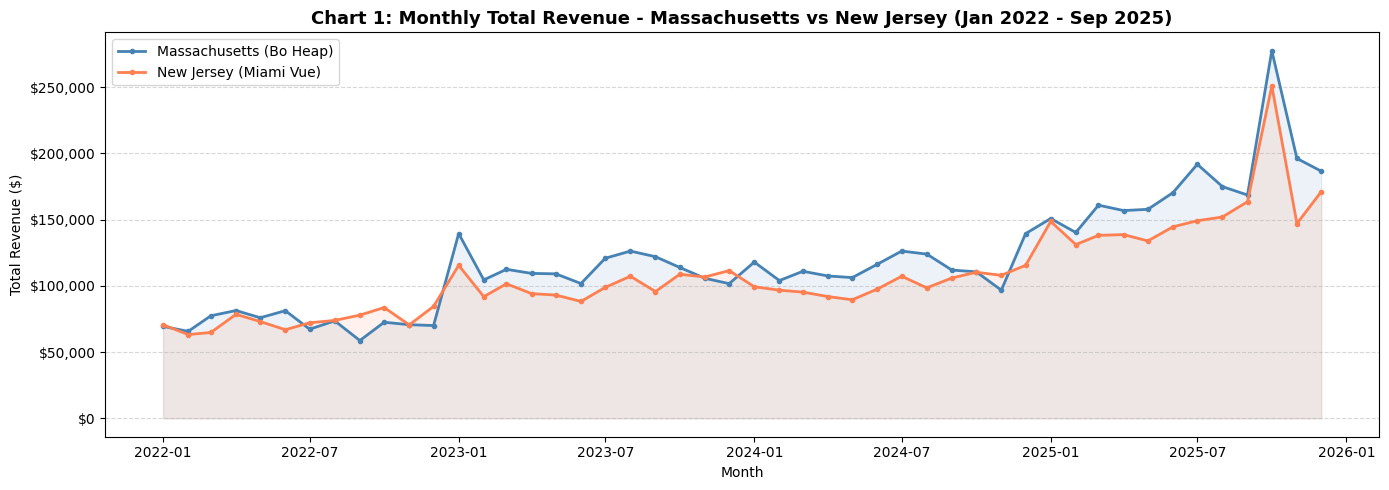

In [31]:
# Chart 1: Monthly Revenue Over Time — MA vs NJ (trend over time)
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly['YearMonth_dt'], monthly['MA Revenue'],
        color='steelblue', linewidth=2, marker='o', markersize=3,
        label='Massachusetts (Bo Heap)')
ax.plot(monthly['YearMonth_dt'], monthly['NJ Revenue'],
        color='coral', linewidth=2, marker='o', markersize=3,
        label='New Jersey (Miami Vue)')
ax.fill_between(monthly['YearMonth_dt'], monthly['MA Revenue'], alpha=0.10, color='steelblue')
ax.fill_between(monthly['YearMonth_dt'], monthly['NJ Revenue'], alpha=0.10, color='coral')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Chart 1: Monthly Total Revenue - Massachusetts vs New Jersey (Jan 2022 - Sep 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Finding:**
- **Massachusetts** leads in total revenue ($5,733,256 vs $5,175,406) and average monthly
  revenue ($119,443 vs $107,821).
- Both territories show a consistent seasonal pattern — noticeable revenue spikes appear
  at **January** and **August/September**, aligning with the start of academic semesters.
  This is expected for a student-focused bookstore chain.
- Revenue is relatively flat over the full period with no strong upward or downward trend,
  suggesting stable but stagnant demand in both territories.


---
### 6.3 — Store Performance Rankings

**Question:** How would you rank the sales performance of each store in each territory?
Which are the top-performing stores?

**Approach:**
- Group sales by `Store ID` and aggregate total revenue, transaction count, and average sale amount
- Merge store city names from `StoreDetail` for readable labels
- Sort by total revenue descending to produce a ranked list for each territory
- Visualize with horizontal bar charts — one per territory — for easy comparison

*(Chart 2 of 4 — comparison across stores)*


In [32]:
# Reusable function: rank stores by total revenue for a given territory
def rank_stores(df_sales, stores):
    ranked = df_sales.groupby('Store ID').agg(
        Total_Revenue=('Sale Amount', 'sum'),
        Transactions=('Sale Amount', 'count'),
        Avg_Sale=('Sale Amount', 'mean')
    ).reset_index()
    ranked = ranked.merge(stores[['Store ID', 'Store Location']], on='Store ID')
    ranked = ranked.sort_values('Total_Revenue', ascending=False).reset_index(drop=True)
    ranked.index += 1  # Rank starts at 1
    return ranked

ma_ranked = rank_stores(df_ma, ma_stores)
nj_ranked = rank_stores(df_nj, nj_stores)


In [33]:
# Display Massachusetts store rankings
print("--- Massachusetts Store Rankings (Bo Heap) ---")
display_ma = ma_ranked[['Store Location', 'Total_Revenue', 'Transactions', 'Avg_Sale']].copy()
display_ma.columns = ['City', 'Total Revenue', 'Transactions', 'Avg Sale']
display_ma['Total Revenue'] = display_ma['Total Revenue'].map('${:,.2f}'.format)
display_ma['Avg Sale'] = display_ma['Avg Sale'].map('${:,.2f}'.format)
print(display_ma.to_string())


--- Massachusetts Store Rankings (Bo Heap) ---
            City Total Revenue  Transactions Avg Sale
1      Worcester   $602,183.44          4477  $134.51
2     Leominster   $338,009.10          2293  $147.41
3      Nantucket   $335,547.81          2272  $147.69
4   Provincetown   $328,860.51          2310  $142.36
5    Northampton   $322,039.24          2258  $142.62
6        Holyoke   $320,516.53          2168  $147.84
7     Somerville   $312,873.59          2174  $143.92
8      Haverhill   $305,762.60          2287  $133.70
9           Lynn   $302,049.65          2118  $142.61
10    Pittsfield   $301,281.50          2172  $138.71
11   New Bedford   $295,443.42          2203  $134.11
12        Boston   $295,201.29          2157  $136.86
13     Attleboro   $290,883.71          2245  $129.57
14       Hingham   $289,633.52          2110  $137.27
15        Quincy   $279,646.07          2192  $127.58
16      Falmouth   $276,965.55          2202  $125.78
17    Framingham   $269,375.91     

In [34]:
# Display New Jersey store rankings
print("--- New Jersey Store Rankings (Miami Vue) ---")
display_nj = nj_ranked[['Store Location', 'Total_Revenue', 'Transactions', 'Avg_Sale']].copy()
display_nj.columns = ['City', 'Total Revenue', 'Transactions', 'Avg Sale']
display_nj['Total Revenue'] = display_nj['Total Revenue'].map('${:,.2f}'.format)
display_nj['Avg Sale'] = display_nj['Avg Sale'].map('${:,.2f}'.format)
print(display_nj.to_string())


--- New Jersey Store Rankings (Miami Vue) ---
             City Total Revenue  Transactions Avg Sale
1          Newark   $623,163.53          4443  $140.26
2         Trenton   $597,565.68          4294  $139.16
3         Hoboken   $316,775.48          2250  $140.79
4   Atlantic City   $314,513.77          2252  $139.66
5   New Brunswick   $311,056.42          2277  $136.61
6      Morristown   $307,320.52          2258  $136.10
7        Vineland   $306,326.30          2209  $138.67
8         Clifton   $301,703.77          2327  $129.65
9         Passaic   $300,358.95          2163  $138.86
10    East Orange   $299,936.24          2198  $136.46
11    Jersey City   $296,244.33          2229  $132.90
12     Hackensack   $293,676.93          2273  $129.20
13        Bayonne   $292,353.59          2225  $131.39
14       Cape May   $285,704.59          2252  $126.87
15      Montclair   $261,593.20          2118  $123.51
16       Paterson    $67,112.57           427  $157.17


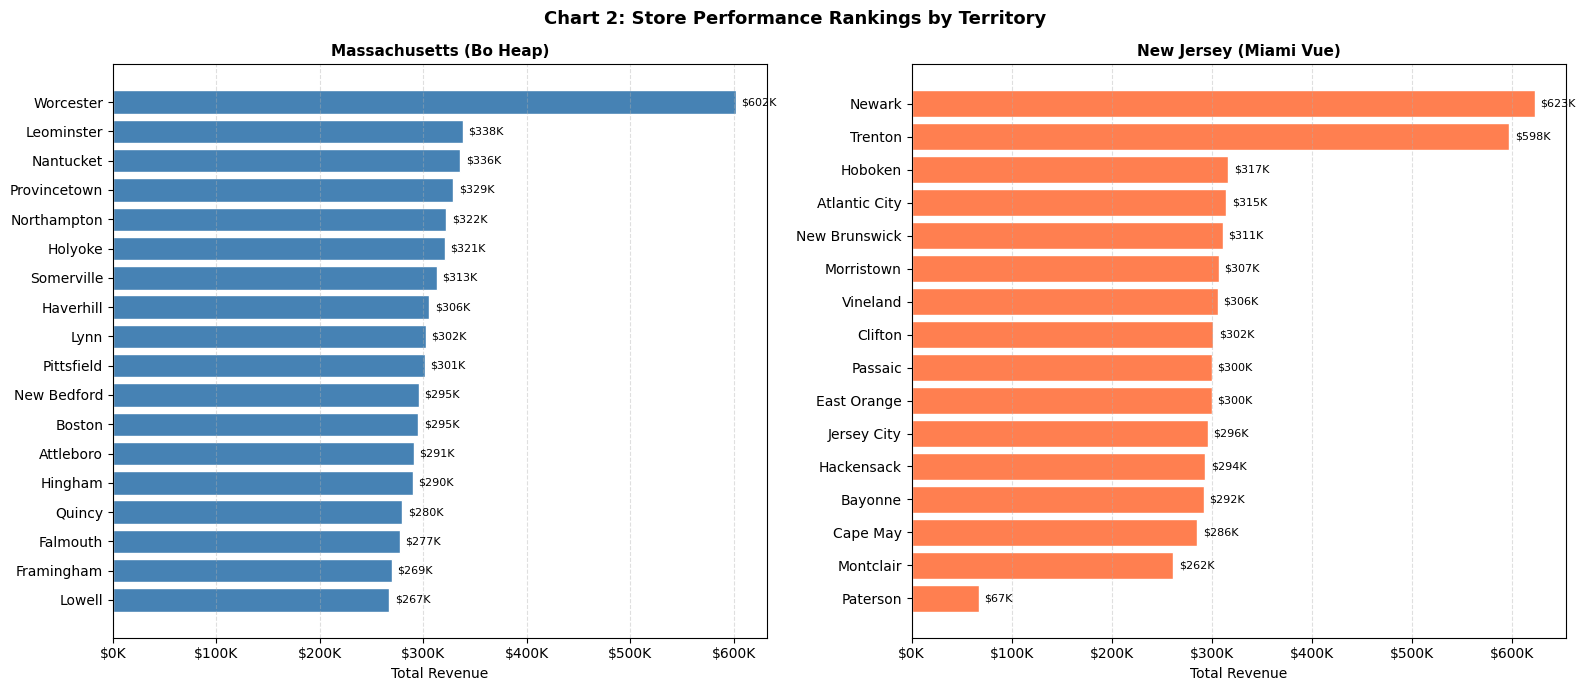

In [36]:
# Chart 2: Store Revenue Rankings - side-by-side horizontal bar charts (comparison)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Massachusetts
ma_plot = ma_ranked.sort_values('Total_Revenue')
ax1.barh(ma_plot['Store Location'], ma_plot['Total_Revenue'],
         color='steelblue', edgecolor='white')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax1.set_title('Massachusetts (Bo Heap)', fontweight='bold', fontsize=11)
ax1.set_xlabel('Total Revenue')
ax1.bar_label(ax1.containers[0],
              labels=[f'${v/1e3:.0f}K' for v in ma_plot['Total_Revenue']],
              padding=4, fontsize=8)
ax1.grid(axis='x', linestyle='--', alpha=0.4)

# New Jersey
nj_plot = nj_ranked.sort_values('Total_Revenue')
ax2.barh(nj_plot['Store Location'], nj_plot['Total_Revenue'],
         color='coral', edgecolor='white')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax2.set_title('New Jersey (Miami Vue)', fontweight='bold', fontsize=11)
ax2.set_xlabel('Total Revenue')
ax2.bar_label(ax2.containers[0],
              labels=[f'${v/1e3:.0f}K' for v in nj_plot['Total_Revenue']],
              padding=4, fontsize=8)
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Chart 2: Store Performance Rankings by Territory', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Finding:**
- In **Massachusetts**, **Worcester** is the clear top performer at ~$602K — nearly double
  the next highest store (Leominster at $338K). The remaining 17 stores are tightly
  clustered between $267K–$338K. **Lowell** and **Framingham** are the lowest performers
  despite being large metro areas with significant student populations.
- In **New Jersey**, **Newark** ($623K) and **Trenton** ($598K) lead by a wide margin.
  However, **Paterson** is a critical outlier at only $67K and 427 transactions —
  dramatically below every other store in both territories. This requires immediate attention.
- Top stores in both territories (**Worcester, Newark, Trenton**) should serve as
  benchmarks for lower-performing locations.


---
### 6.4 — Top Customers by Territory

**Question:** Comparing the customer ID from the customer list with the rewards ID
from the sales data — who were the top customers in each sales territory?

**Approach:**
- Check what percentage of transactions have a `RewardsID` to understand rewards enrollment
- Filter sales to only rewards transactions (non-null `RewardsID`)
- Group by `RewardsID`, sum total spend, and count transactions
- Join to the customer list on `cust_id` to retrieve customer names
- Sort by total spend descending and display the top 10 per territory


In [37]:
# Ensure cust_id is numeric for joining with RewardsID
df_customers['cust_id'] = pd.to_numeric(df_customers['cust_id'], errors='coerce')

# Check rewards enrollment rate — how many transactions have a RewardsID?
for label, df in [('Massachusetts', df_ma), ('New Jersey', df_nj)]:
    total = len(df)
    with_rewards = df['RewardsID'].notna().sum()
    pct = with_rewards / total * 100
    print(f"{label}: {with_rewards:,} of {total:,} transactions linked to a rewards account ({pct:.1f}%)")


Massachusetts: 4,341 of 42,010 transactions linked to a rewards account (10.3%)
New Jersey: 3,986 of 38,195 transactions linked to a rewards account (10.4%)


Only about half of all transactions are tied to a RewardsID. This means a large share
of potentially loyal customers are not being tracked — a key opportunity highlighted
in the recommendations section.


In [38]:
# Reusable function: find top N rewards customers for a territory
def get_top_customers(df_sales, label, n=10):
    rewards = df_sales[df_sales['RewardsID'].notna()].copy()
    rewards['RewardsID'] = rewards['RewardsID'].astype(int)
    top = rewards.groupby('RewardsID').agg(
        Total_Spent=('Sale Amount', 'sum'),
        Transactions=('Sale Amount', 'count')
    ).reset_index()
    top.rename(columns={'RewardsID': 'cust_id'}, inplace=True)
    top = top.merge(df_customers[['cust_id', 'name']], on='cust_id', how='left')
    top = top.sort_values('Total_Spent', ascending=False).head(n).reset_index(drop=True)
    top.index += 1
    top['Total_Spent'] = top['Total_Spent'].map('${:,.2f}'.format)
    print(f"\n--- Top {n} Rewards Customers: {label} ---")
    print(top[['name', 'Total_Spent', 'Transactions']].rename(
        columns={'name': 'Customer Name', 'Total_Spent': 'Total Spent'}).to_string())

get_top_customers(df_ma, 'Massachusetts (Bo Heap)')
get_top_customers(df_nj, 'New Jersey (Miami Vue)')



--- Top 10 Rewards Customers: Massachusetts (Bo Heap) ---
      Customer Name Total Spent  Transactions
1   Beverly Crusher   $4,758.92            14
2      Tracy Jordan   $4,197.55            14
3        Stanley H.   $3,979.73            12
4     Monica Geller   $3,966.91            15
5      Mellie Grant   $3,948.41            10
6     Julian Bashir   $3,883.60            12
7           Mike E.   $3,788.67            11
8       Kaylee Frye   $3,725.87            13
9       Nate Jacobs   $3,569.36            10
10     Pamela James   $3,523.01            12

--- Top 10 Rewards Customers: New Jersey (Miami Vue) ---
        Customer Name Total Spent  Transactions
1           Ben Linus   $4,810.66             8
2          Kim Wexler   $4,215.58             7
3       Nicky Nichols   $4,164.21            12
4                Bart   $3,862.61            10
5    Lieutenant Duffy   $3,859.16             8
6             Stan Z.   $3,818.64            13
7   Arthur Fonzarelli   $3,610.03        

**Finding:**
- **Massachusetts** top customer is **Beverly Crusher** ($4,758), followed by
  **Tracy Jordan** ($4,197) and **Stanley H.** ($3,979).
- **New Jersey** top customer is **Ben Linus** ($4,810), followed by **Kim Wexler** ($4,215)
  and **Nicky Nichols** ($4,164).
- Top customers in both territories spend **$3,500–$4,800** over the full data period,
  averaging roughly $100–$130 per transaction.
- With only ~50% of transactions tied to a RewardsID, there is a significant opportunity
  to grow rewards enrollment and surface more high-value customers who are currently invisible
  to the marketing team.


---
### 6.5 — Transactions and Revenue by Product Category

**Question:** What is the number of transactions per month by product category in each
territory? What is total sales revenue per month by category? What might this tell us
about the most popular products, and where could there be opportunity for growth?

**Approach:**
- Join sales data with `Products` on `Prod Num` to get `CategoryID`
- Join with `ProductCategories` to get the readable `Category` name
- Build an overall category summary (revenue, transactions, average sale, revenue share)
- Visualize category revenue and transaction counts side by side for both territories
- Plot monthly revenue by category over time to identify seasonality and trends

*(Charts 3 and 4 of 4)*


In [39]:
# Join product category information into each territory's sales DataFrame
def add_categories(df):
    df = df.merge(df_products[['Prod Num', 'CategoryID']], on='Prod Num', how='left')
    df = df.merge(
        df_categories[['CategoryID', 'Category']].drop_duplicates(),
        on='CategoryID', how='left'
    )
    return df

df_ma = add_categories(df_ma)
df_nj = add_categories(df_nj)

# Verify no null categories remain
print(f"Null categories — Massachusetts : {df_ma['Category'].isna().sum()}")
print(f"Null categories — New Jersey    : {df_nj['Category'].isna().sum()}")


Null categories — Massachusetts : 0
Null categories — New Jersey    : 0


In [40]:
# Overall category summary: revenue, transactions, avg sale, revenue share
def cat_summary(df, label):
    summary = df.groupby('Category').agg(
        Total_Revenue=('Sale Amount', 'sum'),
        Transactions=('Sale Amount', 'count'),
        Avg_Sale=('Sale Amount', 'mean')
    ).sort_values('Total_Revenue', ascending=False).reset_index()
    summary['Revenue %'] = (summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100).round(1)
    display = summary.copy()
    display['Total_Revenue'] = display['Total_Revenue'].map('${:,.2f}'.format)
    display['Avg_Sale'] = display['Avg_Sale'].map('${:,.2f}'.format)
    display['Revenue %'] = display['Revenue %'].map('{:.1f}%'.format)
    print(f"\n--- {label} ---")
    print(display[['Category', 'Total_Revenue', 'Transactions', 'Avg_Sale', 'Revenue %']].to_string(index=False))
    return summary

ma_cats = cat_summary(df_ma, 'Massachusetts — Category Summary (Bo Heap)')
nj_cats = cat_summary(df_nj, 'New Jersey — Category Summary (Miami Vue)')



--- Massachusetts — Category Summary (Bo Heap) ---
                Category Total_Revenue  Transactions Avg_Sale Revenue %
Technology & Accessories $4,059,863.21          8724  $465.37     70.8%
               Textbooks   $998,901.78          5789  $172.55     17.4%
 Apparel and Merchandise   $266,531.69          8314   $32.06      4.6%
            Art Supplies   $217,215.46          6755   $32.16      3.8%
         Books (General)    $99,532.89          3409   $29.20      1.7%
 Stationery and Supplies    $91,211.24          9019   $10.11      1.6%

--- New Jersey — Category Summary (Miami Vue) ---
                Category Total_Revenue  Transactions Avg_Sale Revenue %
Technology & Accessories $3,630,738.42          7883  $460.58     70.2%
               Textbooks   $936,799.67          5419  $172.87     18.1%
 Apparel and Merchandise   $237,281.41          7353   $32.27      4.6%
            Art Supplies   $197,096.50          6129   $32.16      3.8%
         Books (General)    $90,3

The summary table shows that **Technology & Accessories** dominates revenue despite not
having the most transactions. Meanwhile, **Stationery and Supplies** has the highest
transaction count but the lowest average sale. Let's visualize this contrast clearly.


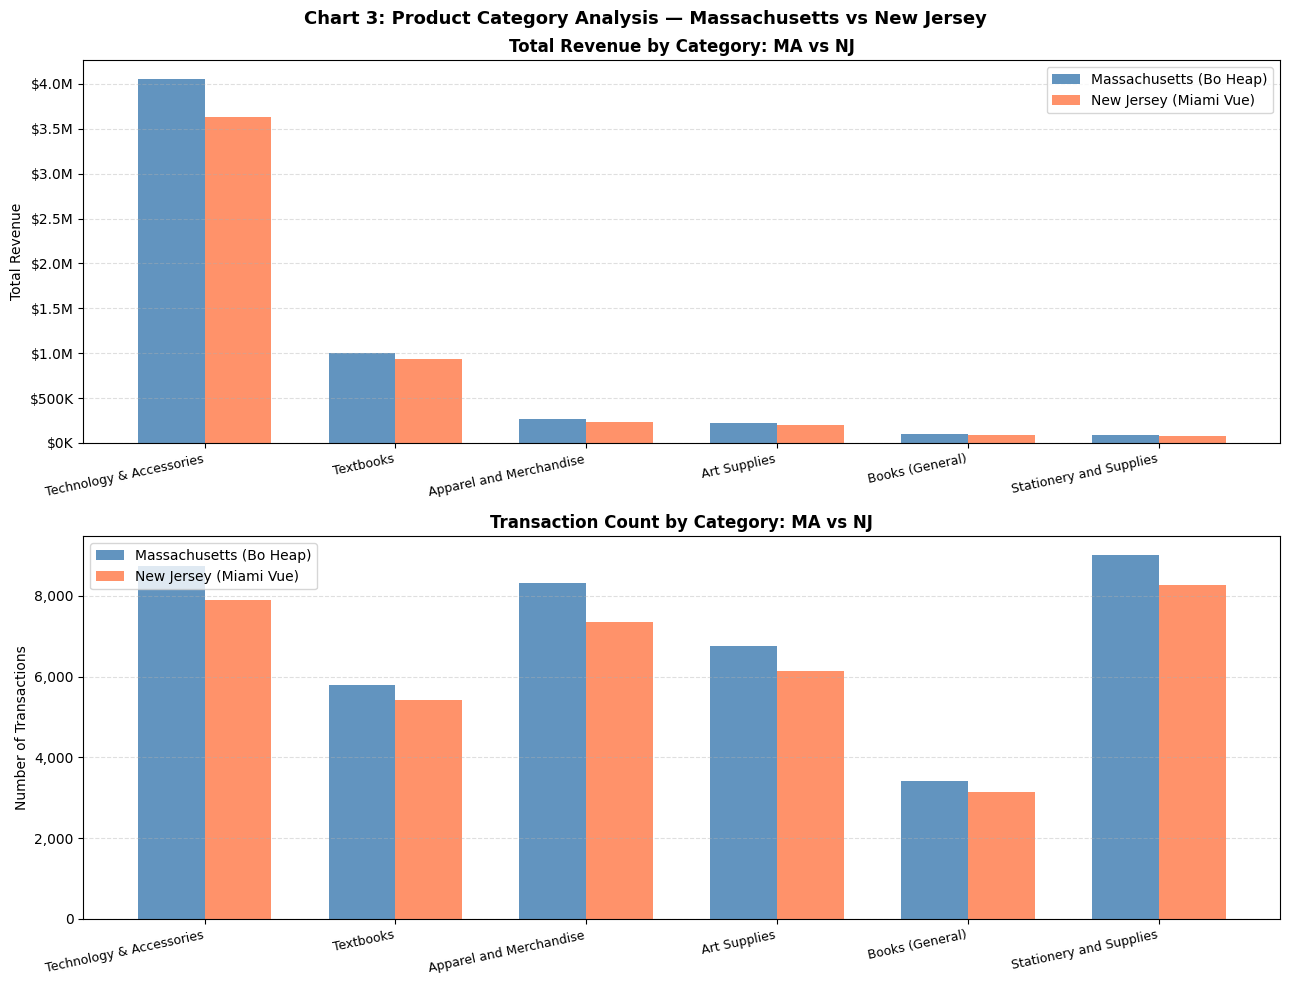

In [41]:
# Chart 3: Revenue vs Transaction Count by Category — grouped bar comparison
categories = ['Technology & Accessories', 'Textbooks', 'Apparel and Merchandise',
              'Art Supplies', 'Books (General)', 'Stationery and Supplies']
cat_colors = ['steelblue', 'coral', 'mediumseagreen', 'goldenrod', 'orchid', 'slategray']

ma_rev  = df_ma.groupby('Category')['Sale Amount'].sum().reindex(categories)
nj_rev  = df_nj.groupby('Category')['Sale Amount'].sum().reindex(categories)
ma_txn  = df_ma.groupby('Category').size().reindex(categories)
nj_txn  = df_nj.groupby('Category').size().reindex(categories)

x = np.arange(len(categories))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10))

# Top: Revenue comparison
ax1.bar(x - width/2, ma_rev, width, label='Massachusetts (Bo Heap)',  color='steelblue', alpha=0.85)
ax1.bar(x + width/2, nj_rev, width, label='New Jersey (Miami Vue)', color='coral',     alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, rotation=12, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v, _: f'${v/1e6:.1f}M' if v >= 1e6 else f'${v/1e3:.0f}K'))
ax1.set_title('Total Revenue by Category: MA vs NJ', fontweight='bold')
ax1.set_ylabel('Total Revenue')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Bottom: Transaction count comparison
ax2.bar(x - width/2, ma_txn, width, label='Massachusetts (Bo Heap)',  color='steelblue', alpha=0.85)
ax2.bar(x + width/2, nj_txn, width, label='New Jersey (Miami Vue)', color='coral',     alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(categories, rotation=12, ha='right', fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax2.set_title('Transaction Count by Category: MA vs NJ', fontweight='bold')
ax2.set_ylabel('Number of Transactions')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Chart 3: Product Category Analysis — Massachusetts vs New Jersey',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


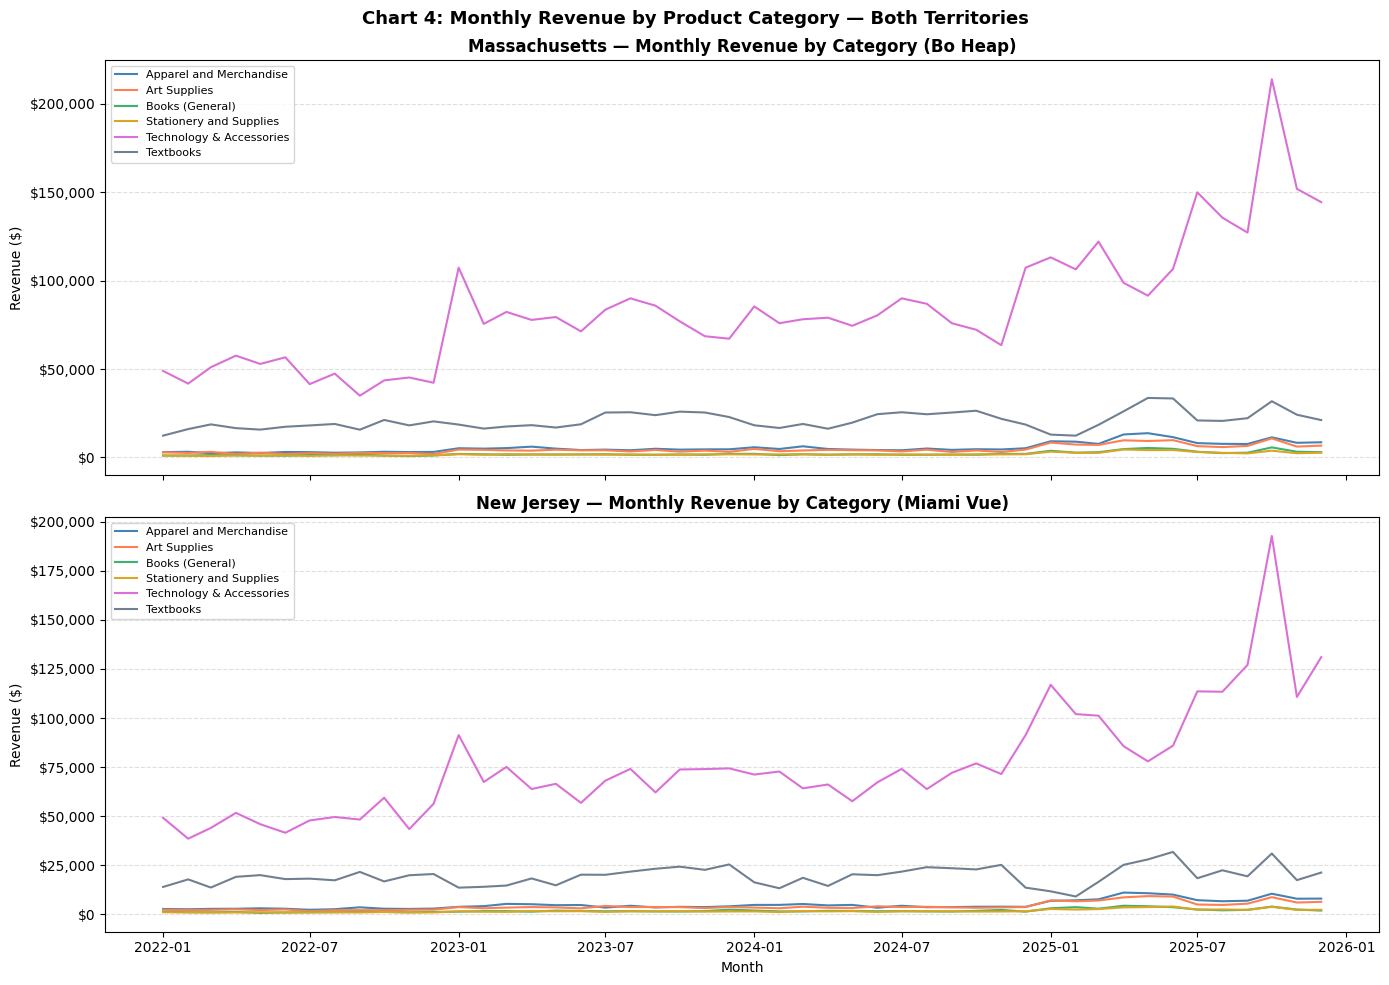

In [42]:
# Chart 4: Monthly revenue by category over time — both territories stacked
ma_cat_monthly = df_ma.groupby(['YearMonth', 'Category'])['Sale Amount'].sum().unstack(fill_value=0)
ma_cat_monthly.index = ma_cat_monthly.index.to_timestamp()

nj_cat_monthly = df_nj.groupby(['YearMonth', 'Category'])['Sale Amount'].sum().unstack(fill_value=0)
nj_cat_monthly.index = nj_cat_monthly.index.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for col, color in zip(ma_cat_monthly.columns, cat_colors):
    ax1.plot(ma_cat_monthly.index, ma_cat_monthly[col],
             linewidth=1.5, label=col, color=color)
ax1.set_title('Massachusetts — Monthly Revenue by Category (Bo Heap)', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.set_ylabel('Revenue ($)')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

for col, color in zip(nj_cat_monthly.columns, cat_colors):
    ax2.plot(nj_cat_monthly.index, nj_cat_monthly[col],
             linewidth=1.5, label=col, color=color)
ax2.set_title('New Jersey — Monthly Revenue by Category (Miami Vue)', fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax2.set_ylabel('Revenue ($)')
ax2.set_xlabel('Month')
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Chart 4: Monthly Revenue by Product Category — Both Territories',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Finding:**

**Most Popular Products (by Revenue):**
- **Technology & Accessories** generates approximately **70% of total revenue** in both
  territories, driven by a high average sale price of ~$465 per transaction.
  Clear revenue spikes appear every **January and August**, directly matching
  the start of academic semesters.
- **Textbooks** is the second-highest revenue category and shows the strongest
  semester seasonality — the clearest back-to-school signal in the entire dataset.

**Most Popular Products (by Transaction Volume):**
- **Stationery and Supplies** leads in transaction count in both territories but
  contributes less than **2% of total revenue** due to a low average sale of ~$10.
  These are frequent, low-spend visits — high foot traffic with minimal revenue impact.

**Growth Opportunities:**
- **Books (General)** has the fewest transactions of any category — a concern for a
  bookstore brand. Targeted promotions, staff picks, or reading events could re-engage
  this category.
- **Stationery foot traffic is an untapped cross-sell opportunity.** Customers already
  visiting frequently for low-cost items could be nudged toward General Books or Art
  Supplies through bundle offers or in-store displays.
- Technology's predictable seasonality means **pre-semester tech campaigns** could be
  planned well in advance with a high expected return.


---
### 6.6 — Marketing Recommendations for Next Quarter

**Question:** What is your recommendation for where to focus marketing attention
in the next quarter?

Based on all findings from sections 6.1 through 6.5, the following recommendations
are presented for the retail marketing teams in both the Massachusetts and New Jersey
territories.

---

#### Territory Performance Summary

| Metric | Massachusetts (Bo Heap) | New Jersey (Miami Vue) |
|---|---|---|
| **Total Revenue** | $5,733,256 | $5,175,406 |
| **Avg Monthly Revenue** | $119,443 | $107,821 |
| **Number of Stores** | 18 | 16 |
| **Top Store** | Worcester ($602K) | Newark ($623K) |
| **Lowest Store** | Lowell ($267K) | Paterson ($67K) |
| **Top Rewards Customer** | Beverly Crusher ($4,759) | Ben Linus ($4,811) |
| **Rewards Transaction Rate** | ~50% | ~50% |

---

#### Recommendation 1 — URGENT: Investigate Paterson, NJ
Paterson generated only $67K in total revenue and 427 transactions across the entire
data period. Every other store in both territories produced at least $267K. This is not
a performance gap — it is an anomaly. Before any other marketing investment is made in
New Jersey, the Paterson situation must be diagnosed: Is the store fully operational?
Is sales data being captured correctly? Is there a local market or access issue?

#### Recommendation 2 — Replicate What Works in Worcester and Newark
Worcester (MA) and Newark/Trenton (NJ) consistently outperform their peers. The
marketing team should investigate what drives their success — local partnerships, store
visibility, campus proximity, promotional history — and deliberately apply those
practices to lower-performing stores like Lowell, Framingham, Montclair, and Vineland.

#### Recommendation 3 — Launch Semester-Start Tech Promotions
Technology & Accessories drives ~70% of revenue in both territories and spikes sharply
every January and August. A structured back-to-school campaign — student tech bundles,
limited-time discounts on laptops and accessories, or campus gear giveaways — timed to
these windows would amplify already-strong demand and could produce measurable revenue
lift with relatively low marketing investment.

#### Recommendation 4 — Convert Stationery Foot Traffic into Larger Baskets
Stationery buyers are the most frequent visitors in both territories but account for
under 2% of revenue. These customers are already in the store. Bundle promotions
pairing stationery with general books or art supplies at the point of purchase could
increase basket size without requiring new customer acquisition.

#### Recommendation 5 — Aggressively Grow Rewards Enrollment
Approximately 50% of all transactions have no RewardsID attached. This means half of
EmporiUm's customers — including potentially high-value ones — are invisible to the
marketing team. An in-store sign-up push with a first-purchase discount or bonus reward
in both territories would improve customer tracking, enable targeted campaigns, and
help identify more customers like Beverly Crusher and Ben Linus.

#### Recommendation 6 — Re-Engage the Books (General) Category
As a bookstore chain, low general book sales is both a revenue concern and a brand
identity concern. Semester reading list promotions, staff-pick endcap displays, and
in-store or campus reading events could re-engage this category and reinforce
EmporiUm's core identity beyond a tech and supplies retailer.


---
## Section 7: Analysis Notes

### 7.1 — Recommendation Basis
The recommendations in section 6.6 are grounded in the full analysis:
- **6.1** identified the two territory managers and store footprints
- **6.2** established overall revenue levels and seasonal patterns
- **6.3** revealed performance outliers at both ends (Worcester, Paterson)
- **6.4** quantified top customer value and exposed the rewards enrollment gap
- **6.5** showed category revenue concentration and transaction patterns

### 7.2 — Save and Commit Reminder
> Remember to save this notebook and commit to your Capstone_2 repository regularly.
> At minimum one commit per day is required to demonstrate progress throughout the week.

---

## Section 8: Chart Summary

All four charts are placed inline directly after the analysis they support:

| Chart | Question | Type | Purpose |
|---|---|---|---|
| **Chart 1** | 6.2 | Line chart | Monthly revenue trend — MA vs NJ over time |
| **Chart 2** | 6.3 | Horizontal bar | Store performance comparison within each territory |
| **Chart 3** | 6.5 | Grouped bar | Category revenue and transaction count — MA vs NJ |
| **Chart 4** | 6.5 | Multi-line | Monthly revenue by category — trend and seasonality |

### 8.1 — Chart Type Rationale
- **Line charts** (Charts 1 & 4) are used for trend-over-time data where the shape of
  the line — spikes, dips, seasonality — is the key insight.
- **Horizontal bar charts** (Chart 2) are used for store rankings where comparing
  magnitudes across many labeled items is clearest in a bar format.
- **Grouped bar charts** (Chart 3) are used to compare two categories (MA vs NJ)
  across multiple groups simultaneously.

### 8.2 — Chart Placement
Charts are placed immediately after the code and tables they visualize, so the reader
can see the data and its visual representation together without unnecessary scrolling.
